In [391]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.stats import norm
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [434]:
tickers = [
    "NIFTYBEES.NS",
    "JUNIORBEES.NS",
    "GOLDBEES.NS",
    "LIQUIDCASE.NS"
]

In [435]:
end_date = datetime.today()
start_date = end_date - timedelta(365)

In [436]:
adj_close = pd.DataFrame()

for ticker in tickers:
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
    )

    adj_close[ticker] = data["Close"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [437]:
print(adj_close.head())

            NIFTYBEES.NS  JUNIORBEES.NS  GOLDBEES.NS  LIQUIDCASE.NS
Date                                                               
2025-10-06    283.070007     737.510010    99.220001     110.750000
2025-10-07    283.410004     736.159973    99.660004     110.779999
2025-10-08    282.380005     731.109985   101.690002     110.779999
2025-10-09    284.049988     734.770020   101.470001     110.809998
2025-10-10    285.519989     736.880005   100.669998     110.860001


In [438]:
log_returns = np.log(adj_close / adj_close.shift(1))
log_returns = log_returns.dropna()

In [439]:
def expected_return(weights, log_retruns):
    return np.sum(np.mean(log_retruns) * weights)

In [440]:
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

In [441]:
def sharp_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return (expected_return(weights, log_returns) - risk_free_rate) / standard_deviation(weights, cov_matrix)

In [442]:
cov_matrix = log_returns.cov()

In [443]:
cov_matrix

,NIFTYBEES.NS,JUNIORBEES.NS,GOLDBEES.NS,LIQUIDCASE.NS
NIFTYBEES.NS,6.125946e-05,6.980637e-05,4.684761e-05,3.215063e-08
JUNIORBEES.NS,6.980637e-05,1.049894e-04,6.580886e-05,-1.417586e-08
GOLDBEES.NS,4.684761e-05,6.580886e-05,4.244161e-04,-6.434083e-09
LIQUIDCASE.NS,3.215063e-08,-1.417586e-08,-6.434083e-09,1.985711e-08


In [444]:
portfolio_value = 100000
weights = np.array([1 / len(tickers)] * len(tickers))

In [445]:
portfolio_expected_return = expected_return(weights, log_returns)
portfolio_std = standard_deviation(weights, cov_matrix)

In [446]:
print(f"Expected Returns    : {portfolio_expected_return:.4f}")
print(f"Standard Deviation  : {portfolio_std:.4f}")

Expected Returns    : 0.0002
Standard Deviation  : 0.0077


In [447]:
confidence_level = 0.05

VaR = norm.ppf(confidence_level, portfolio_expected_return, portfolio_std)

In [448]:
print(VaR)
print(VaR * np.sqrt(30))

-0.012546359412081574
-0.06871924064564332


In [449]:
# GENETIC ALGORITHM IMPLEMENTATION

In [454]:
POPULATION_SIZE = 100
GENOME_LENGTH = len(tickers)
MUTATION_RATE = 0.01
CROSSOVER_RATE = 0.7
GENERATIONS = 300

In [472]:
def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)


def random_genome(length):
    return np.random.randn(length)


def init_population(population_size, genome_length):
    return [
        random_genome(genome_length)
        for _ in range(population_size)
    ]


def fitness(genome, log_returns, cov_matrix):
    weights = softmax(genome)

    return sharp_ratio(
        weights,
        log_returns,
        cov_matrix,
        0
    )


def select_parent(population, fitness_values):
    fitness_values = np.asarray(fitness_values)

    # Make all fitness values positive
    adjusted_fitness = (
        fitness_values
        - np.min(fitness_values)
        + 1e-8
    )

    total_fitness = np.sum(adjusted_fitness)
    pick = np.random.uniform(0, total_fitness)
    current = 0

    for individual, fitness_value in zip(
        population,
        adjusted_fitness
    ):
        current += fitness_value
        if current >= pick:
            return individual, False

    return population[-1], False


def crossover(parent_a, parent_b):
    if np.random.random() < CROSSOVER_RATE:
        crossover_point = np.random.randint(
            1,
            len(parent_a)
        )

        child_a = np.concatenate([
            parent_a[:crossover_point],
            parent_b[crossover_point:]
        ])

        child_b = np.concatenate([
            parent_b[:crossover_point],
            parent_a[crossover_point:]
        ])

        return child_a, child_b

    return parent_a.copy(), parent_b.copy()


def mutate(genome):
    genome = genome.copy()

    for i in range(len(genome)):
        if np.random.random() < MUTATION_RATE:
            genome[i] += np.random.normal(
                loc=0.0,
                scale=0.2
            )

    return genome

In [473]:
def genetic_algorithm(log_returns, cov_matrix):

    population = init_population(
        POPULATION_SIZE,
        GENOME_LENGTH
    )

    for generation in range(GENERATIONS):
        fitness_values = np.array([
            fitness(
                genome,
                log_returns,
                cov_matrix
            )
            for genome in population
        ])

        new_population = []
        for _ in range(POPULATION_SIZE // 2):
            parent_a, _ = select_parent(
                population,
                fitness_values
            )

            parent_b, _ = select_parent(
                population,
                fitness_values
            )

            child_a, child_b = crossover(
                parent_a,
                parent_b
            )

            child_a = mutate(child_a)
            child_b = mutate(child_b)

            new_population.extend([
                child_a,
                child_b
            ])

        population = new_population[:POPULATION_SIZE]

        # Best individual
        best_idx = np.argmax(fitness_values)
        best_fitness = fitness_values[best_idx]

        clear_output(wait=True)

        print(
            f"Generation {generation + 1}/{GENERATIONS} "
            f"| Best Sharpe = {best_fitness:.4f}"
        )

    # Final evaluation
    fitness_values = np.array([
        fitness(
            genome,
            log_returns,
            cov_matrix
        )
        for genome in population
    ])

    idx = np.argmax(fitness_values)

    best_genome = population[idx]
    best_fitness = fitness_values[idx]

    best_solution = softmax(best_genome)

    print("\nBest Solution:")
    print(best_solution)

    print("\nWeight Sum:")
    print(np.sum(best_solution))

    print("\nBest Fitness:")
    print(best_fitness)

    plt.plot(fitness_values)
    plt.xlabel("Individual")
    plt.ylabel("Sharpe Ratio")
    plt.show()

    return best_solution, best_fitness

Generation 300/300 | Best Sharpe = 1.1756

Best Solution:
[1.95698941e-06 3.00396921e-04 1.72128531e-05 9.99680433e-01]

Weight Sum:
1.0

Best Fitness:
1.1755977175536267


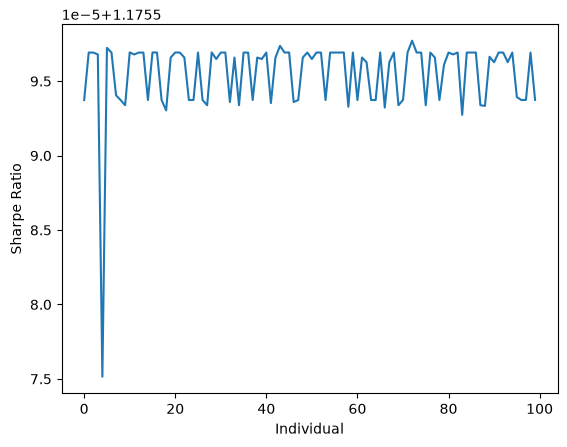

In [474]:
best_solution, best_fitness = genetic_algorithm(log_returns, cov_matrix)

In [478]:
for ticker, item in zip(tickers, best_solution * portfolio_value):
    print(f"{ticker}: {item:.4f}")

NIFTYBEES.NS: 0.1957
JUNIORBEES.NS: 30.0397
GOLDBEES.NS: 1.7213
LIQUIDCASE.NS: 99968.0433
